The objective of this notebook is to find the total number of particles N between 1 and 5000 um using a cumulative sum. Instead of binning particles into bins, and then defining the slope and intercept of normalised size distributions in a log log scale, we define a cumulative sum of total particles with size superior to D, D being the limit of a bin given by authors. This avoids the necessity to propose hypotheses about distribution inside the bin, and this method is independent of bin sizes used by authors of a histogram. 
This notebook shows that the cumulative sum method is more precise than the method previously used, regardless of the bin sizes.

In [1]:
import numpy as np                       
import matplotlib.pyplot as plt 
from scipy.stats import linregress
import pandas as pd

In [2]:
def sample_power_law(xmin_spl,xmax_spl,b_spl,distribution_spl):
    
    """ This function samples particle size following power law distibution """
    
    exponent = b_spl + 1
    norm = (xmax_spl**exponent - xmin_spl**exponent)
    MP_size = (distribution_spl * norm + xmin_spl**exponent) ** (1 / exponent)
    return MP_size

In [3]:
def simulated_sampling_visual(xmin_ssv, xmax_ssv, LOD_min_ssv,LOD_max_ssv, b_ssv, samples_ssv, print_graph):
    
    """ Returns the distribution of MP sizes within the LOD interval sampled from MP 1-5000 distribution. 
        A visual representation in the form of a histogram is proposed.
        We assume that experimenters measured 100% of the particles present in the environmental matrix. """
    
    part_total = sample_power_law(xmin_ssv, xmax_ssv, b_ssv, samples_ssv)
    part_dispo = part_total[(part_total > LOD_min_ssv) & (part_total < LOD_max_ssv)]
    
    size_distribution = np.sort(part_dispo)
    
    if len(part_dispo) == 0:
        print('Problem: there are no particles in the LOD range',LOD_min_ss,LOD_max_ss)
        return np.array([]) 
    
    if print_graph == 0:
        print('There is ', len(part_total), 'particles in the matrice.') 
        print('We sampled ', len(part_dispo), 'particles within the LOD interval.')
        
        # Log Log scale histogram
        
        plt.figure(figsize=(8, 5))
        plt.hist(part_total, bins=np.logspace(np.log10(xmin_ssv), np.log10(xmax_ssv), 50), edgecolor='black')
        plt.hist(part_dispo, bins=np.logspace(np.log10(xmin_ssv), np.log10(xmax_ssv), 50), edgecolor='black')
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Particle size (x)')
        plt.ylabel('Count')
        plt.title('Histogram of Particle Sizes (log scale)')
        plt.grid(True, which="both", ls="--")
        plt.tight_layout()
        plt.show()
    
    return size_distribution

# Simplified version
def simulated_sampling(xmin_ss, xmax_ss, LOD_min_ss,LOD_max_ss, b_ss, samples_ss):
    
    """ Returns the distribution of MP sizes within the LOD interval sampled from MP 1-5000 distribution. """
    
    part_total = sample_power_law(xmin_ss, xmax_ss, b_ss, samples_ss)
    part_dispo = part_total[(part_total > LOD_min_ss) & (part_total < LOD_max_ss)]

    if len(part_dispo) == 0:
        print('Problem: there are no particles in the LOD range',LOD_min_ss,LOD_max_ss)
        return np.array([]) 

    size_distribution = np.sort(part_dispo)

    return size_distribution

def particle_size_distribution(LOD_min, LOD_max, total_concentration, slope_cumsum):
    slope = slope_cumsum-1
    intercept = (total_concentration*(slope+1))/(LOD_max**(slope+1)-LOD_min**(slope+1))

    New_N=(intercept/(slope+1))/(5000**(slope+1)-1**(slope+1))
    
    return slope, intercept, New_N
    

We define the parameters describing the size distribution of the particles in this simulation.\
Since the microplastics follow a power law distribution $ax^b$ where $b$ is the slope and $10^a$ is the intercept of a linear regression in log log scale, we define $b$ the slope of the distribution as a principal parameter of the distribution.\
We define lower and upper limits of detection. The upper LOD is an important parameter that influences the simulated sampling.\
We define the number of sampling campaigns and number of particles in the 1-5000 range that we aim to re-find using the cumulative sum. \
A histogram of the first sampling campaign is shown or visualisation.

There is  100000 particles in the matrice.
We sampled  5105 particles within the LOD interval.


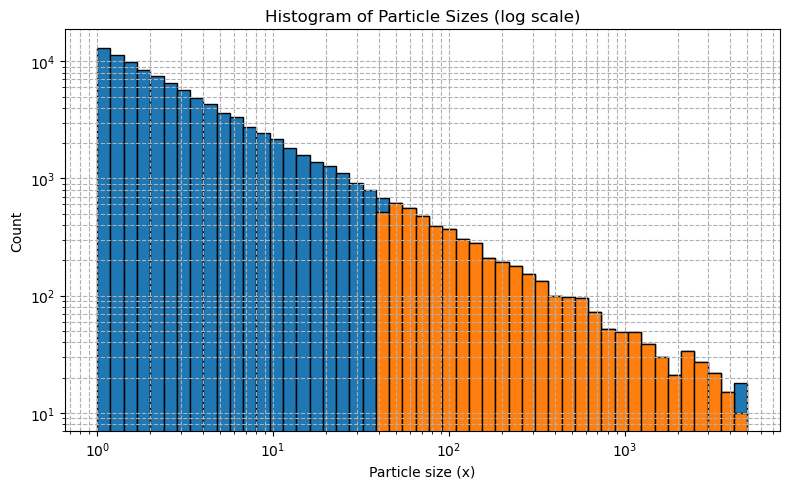

In [4]:
#slope
slope_th = -1.8

# MP range
xmin = 1
xmax = 5000

# Physical limits of detection
LOD_low = 40
LOD_high = 4500

# Sampling                    
sampling_campaigns = 20                         
number_of_particles_full_range = 100000          

# Multiple sampling campaigns
all_samplings=[]
for i in range(sampling_campaigns):
    random_sequence = np.random.uniform(0, 1, number_of_particles_full_range)
    size_distribution=simulated_sampling_visual(xmin_ssv=xmin, xmax_ssv=xmax, LOD_min_ssv=LOD_low,
                                                LOD_max_ssv=LOD_high, b_ssv=slope_th, samples_ssv=random_sequence,print_graph=i)
    all_samplings.append(size_distribution)
    

One can choose which bin to use in this demonstration: regular_bins, irregular_bins or typical_bins to see the effect of binning on the results\
Next, we define cumulative counts and plot the size distribution. We plot only the first sampling campaign to show the distribution. All samplings are stored in all_cumulative_counts.

In [5]:

# Regular bins
bin_length = 10
regular_bins = np.arange(LOD_low,LOD_high+1-100,bin_length)

# Irregular bins
initial_step = 5 # depends on lower LOD and number of particles sampled
irregular_bins=[]
step = initial_step
current_edge = LOD_low
edges = [current_edge]

while True:
    next_step = step
    current_edge += next_step
    if current_edge > LOD_high:
        break
    edges.append(current_edge)
    step *= 2
irregular_bins = edges

# Typical bins from MPsizeBase
bin_length_random=np.array([10,15,30,30,50,50,100,100,125,205,200,200,200,200,200,200,400,400,500,500])
typical_bins=[LOD_low]
for length in bin_length_random:
    next_bin = typical_bins[-1] + length
    if next_bin <= LOD_high:
        typical_bins.append(next_bin)
    else:
        break  
typical_bins = np.array(typical_bins)


[5105 4649 3934 2989 2068 1299  745  382  186   66]


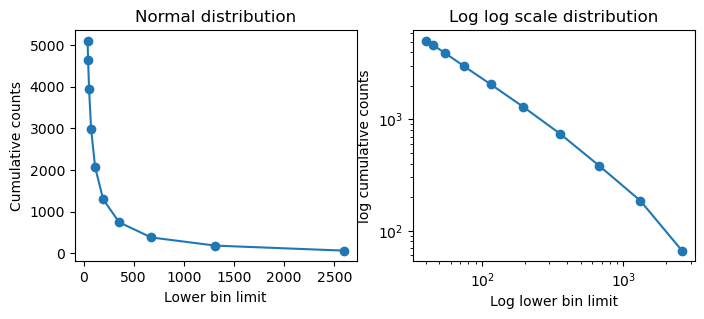

In [6]:
lower_bin_limits = irregular_bins
all_cumulative_counts=[]
for i in range(sampling_campaigns):
    cumulative_counts = np.array([(all_samplings[i] >=limit).sum() for limit in lower_bin_limits])
    all_cumulative_counts.append(cumulative_counts)
    if i == 0:
        print(cumulative_counts)
        fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(8, 3))

        ax1.plot(lower_bin_limits, cumulative_counts, marker='o')
        ax1.set_xlabel('Lower bin limit')
        ax1.set_ylabel("Cumulative counts")
        ax1.set_title('Normal distribution')

        ax2.loglog(lower_bin_limits, cumulative_counts, marker='o')
        ax2.set_xlabel('Log lower bin limit')
        ax2.set_ylabel("log cumulative counts")
        ax2.set_title('Log log scale distribution')

all_cumulative_counts=np.array(all_cumulative_counts)


The power law distribution has slightly disturbed tail beaceuse of the lack of big particles. Thanks to the plot, one can choose the points we do not want to include in the linear regression computation. This value is specific for each sampling parameters and depends greatly on LOD, slope and n - number of sampled particles). One has to adjust it from study to another. A pattern for defining the threshold bin is defined in the notebook Error field, but is not used for instance.

In [7]:
minimal_bins_used = 7
counts_kept_all=[]
bins_kept_all=[]
for i in range(sampling_campaigns):
    counts=all_cumulative_counts[i]
    counts_kept = counts[:minimal_bins_used]
    bins_kept = lower_bin_limits[:minimal_bins_used]
    counts_kept_all.append(counts_kept)
    bins_kept_all.append(bins_kept)

Next, we find the slope and the interept of the cummulative size distribution in a log log scale. The cumulative sum slope is proportional to the power-law slope (Clauset et al. 2019) using $slope_{th}=slope_{cumsum}-1$.\
Again, the first distribution is plotted for visual purpose.

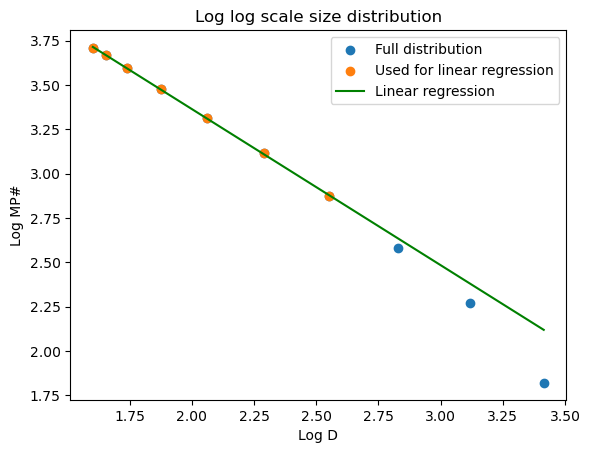

In [8]:
all_slopes_cumsum=[]
all_intercepts_cumsum=[]

log_bins = np.log10(lower_bin_limits)
log_counts = np.log10(all_cumulative_counts)
log_bins_kept = np.log10(bins_kept_all)
log_counts_kept = np.log10(counts_kept_all)
for i in range(sampling_campaigns):
    slope_cumsum=linregress(log_bins_kept[i],log_counts_kept[i]).slope
    intercept_cumsum=linregress(log_bins_kept[i],log_counts_kept[i]).intercept
    if i == 0:
        plt.scatter(log_bins,log_counts[i],marker='o',label='Full distribution')
        plt.scatter(log_bins_kept[i],log_counts_kept[i],marker='o',label='Used for linear regression')
        plt.plot(log_bins,slope_cumsum*log_bins+intercept_cumsum, label='Linear regression',color='green')
        plt.xlabel('Log D')
        plt.ylabel("Log MP#")
        plt.title('Log log scale size distribution')
        plt.legend()
    all_slopes_cumsum.append(slope_cumsum)
    all_intercepts_cumsum.append(intercept_cumsum)
    

Using the linear equation $log(counts)=slope*log(size)+intercept$ we can find N(>1), the number of all particle with size superior to xmin=1 um. From this value, we subtract the value of particles larger than xmax = 5000 um. Thus, we get N, the number of total microplastics within the range 1-5000 um.\
We do this computations for each sampling campaign and than we find the mean value over all sampling campaigns. We calculate the error on N and on slope, as the difference between computed value and value imposed as a starting parameter.

In [9]:
all_slopes = np.array(all_slopes_cumsum)-1
all_slopes_err = all_slopes-slope_th

all_N=[]
all_N_err=[]
for i in range(sampling_campaigns):
    N_1 = all_slopes_cumsum[i]*np.log10(1)+all_intercepts_cumsum[i]
    N_5000=(all_slopes_cumsum[i]*np.log10(5000)+all_intercepts_cumsum[i])
    N = 10**N_1-10**N_5000
    all_N.append(N)
    all_N_err=all_N[i]-number_of_particles_full_range    
print('The mean total number of particles within 1-5000 um range over all samplings is',round(np.mean(all_N)))
print('The mean error on N is', round(np.mean(np.absolute(all_N_err))),'particles. If negative value: method underestimates the total number of particles.')
print('The error is of ', np.mean(np.absolute(all_N_err))*100/number_of_particles_full_range,'%')
print('Mean error on slope is', np.mean(np.absolute(all_slopes_err)))


The mean total number of particles within 1-5000 um range over all samplings is 119135
The mean error on N is 17053 particles. If negative value: method underestimates the total number of particles.
The error is of  17.052891775698868 %
Mean error on slope is 0.05134801174300202


In [10]:
total_concentration=np.mean(all_N)
LOD_min=1
LOD_max=5000
slope, intercept, New_N2=particle_size_distribution(LOD_min, LOD_max, total_concentration, np.mean(all_slopes_cumsum))
New_N2

np.float64(119304.31357717508)

We can study the dependance of the precision on N while varying different parameters
### Number of particles in 1-5000 range - using irregular bins step*2

In [11]:
#slope
slope_th = -2.

# MP range
xmin = 1
xmax = 5000

# Physical limits of detection
LOD_low = 10
LOD_high = 4500

# Sampling                    
sampling_campaigns = 100                         
number_of_particles_full_range = np.arange(500,50501,500)       

# Multiple sampling campaigns
n_sampled=[]
all_samplings_particles=[]
for j in range(len(number_of_particles_full_range)):
    all_samplings=[]
    number_of_particles=[]
    for i in range(sampling_campaigns):
        random_sequence = np.random.uniform(0, 1, number_of_particles_full_range[j])
        size_distribution=simulated_sampling(xmin_ss=xmin, xmax_ss=xmax, LOD_min_ss=LOD_low,
                                                LOD_max_ss=LOD_high, b_ss=slope_th, samples_ss=random_sequence)
        all_samplings.append(size_distribution)
        number_of_particles.append(len(size_distribution))
    all_samplings_particles.append(all_samplings)
    n_sampled.append(np.mean(number_of_particles))
    

In [12]:
# Regular bins
bin_length = 150
regular_bins = np.arange(LOD_low,LOD_high+1-100,bin_length)

# Irregular bins
initial_step = 10
irregular_bins=[]
step = initial_step
current_edge = LOD_low
edges = [current_edge]

while True:
    next_step = step
    current_edge += next_step
    if current_edge > LOD_high:
        break
    edges.append(current_edge)
    step *= 2  # next step doubles
irregular_bins = edges

# Random bins
bin_length_random=np.array([10,15,30,30,50,50,100,100,125,205,200,200,200,200,200,200,400,400,500,500])
typical_bins=[LOD_low]
for length in bin_length_random:
    next_bin = typical_bins[-1] + length
    if next_bin <= LOD_high:
        typical_bins.append(next_bin)
    else:
        break  
typical_bins = np.array(typical_bins)


[48 26  8  3  1  1  1  1  0]


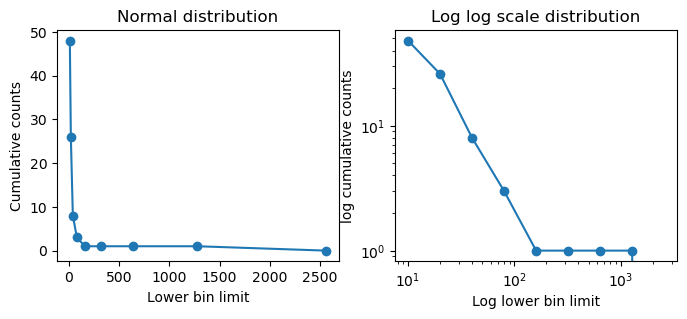

In [13]:
lower_bin_limits = irregular_bins
all_cumulative_counts_particles=[]
for j in range(len(number_of_particles_full_range)):
    all_cumulative_counts=[]
    for i in range(sampling_campaigns):
        cumulative_counts = np.array([(all_samplings_particles[j][i] >=limit).sum() for limit in lower_bin_limits])
        all_cumulative_counts.append(cumulative_counts)
        if i == 0 and j==0:
            print(cumulative_counts)
            fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(8, 3))

            ax1.plot(lower_bin_limits, cumulative_counts, marker='o')
            ax1.set_xlabel('Lower bin limit')
            ax1.set_ylabel("Cumulative counts")
            ax1.set_title('Normal distribution')

            ax2.loglog(lower_bin_limits, cumulative_counts, marker='o')
            ax2.set_xlabel('Log lower bin limit')
            ax2.set_ylabel("log cumulative counts")
            ax2.set_title('Log log scale distribution')
            plt.show()

    all_cumulative_counts_particles.append(all_cumulative_counts)
    

In [14]:
minimal_bins_used = 4
counts_kept_all_particles=[]
bins_kept_all_particles=[]
for j in range(len(number_of_particles_full_range)):
    counts_kept_all=[]
    bins_kept_all=[]
    for i in range(sampling_campaigns):
        counts=all_cumulative_counts_particles[j][i]
        counts_kept = counts[:minimal_bins_used]
        bins_kept = lower_bin_limits[:minimal_bins_used]
        counts_kept_all.append(counts_kept)
        bins_kept_all.append(bins_kept)
    counts_kept_all_particles.append(counts_kept_all)
    bins_kept_all_particles.append(bins_kept_all)

/tmp/ipykernel_47561/2951432751.py:5: RuntimeWarning: divide by zero encountered in log10
  log_counts = np.log10(all_cumulative_counts_particles)


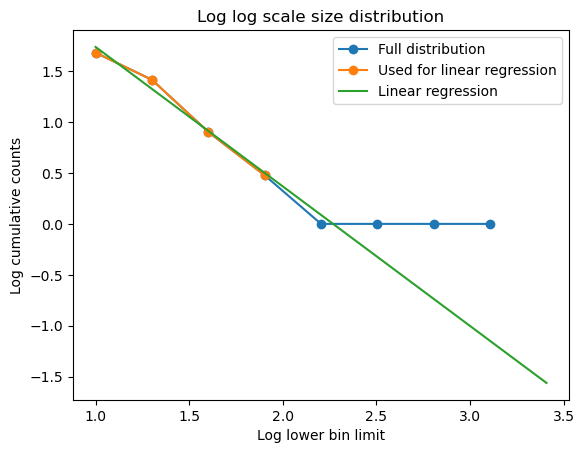

In [15]:
all_slopes_cumsum_particles=[]
all_intercepts_cumsum_particles=[]

log_bins = np.log10(lower_bin_limits)
log_counts = np.log10(all_cumulative_counts_particles)
log_bins_kept_all_particles = np.log10(bins_kept_all_particles)
log_counts_kept_all_particles = np.log10(counts_kept_all_particles)

for j in range(len(number_of_particles_full_range)):
    all_slopes_cumsum=[]
    all_intercepts_cumsum=[]
    for i in range(sampling_campaigns):
        slope_cumsum=linregress(log_bins_kept_all_particles[j][i],log_counts_kept_all_particles[j][i]).slope
        intercept_cumsum=linregress(log_bins_kept_all_particles[j][i],log_counts_kept_all_particles[j][i]).intercept
        if i == 0 and j==0:
            plt.plot(log_bins,log_counts[j][i],marker='o',label='Full distribution')
            plt.plot(log_bins_kept_all_particles[j][i],log_counts_kept_all_particles[j][i],marker='o',label='Used for linear regression')
            plt.plot(log_bins,slope_cumsum*log_bins+intercept_cumsum, label='Linear regression')
            plt.xlabel('Log lower bin limit')
            plt.ylabel("Log cumulative counts")
            plt.title('Log log scale size distribution')
            plt.legend()
            plt.show()
        all_slopes_cumsum.append(slope_cumsum)
        all_intercepts_cumsum.append(intercept_cumsum)
    all_slopes_cumsum_particles.append(all_slopes_cumsum)
    all_intercepts_cumsum_particles.append(all_intercepts_cumsum)
    

In [16]:
all_slopes_particles = np.array(all_slopes_cumsum_particles)-1
all_slopes_err_particles = all_slopes_particles-slope_th
all_slopes_err_particles_mean=[]
all_N_particles=[]
all_N_err_particles=[]

for j in range(len(number_of_particles_full_range)):
    all_N=[]
    all_N_err=[]
    for i in range(sampling_campaigns):
        N_1 = all_slopes_cumsum_particles[j][i]*np.log10(1)+all_intercepts_cumsum_particles[j][i]
        N_5000=(all_slopes_cumsum_particles[j][i]*np.log10(5000)+all_intercepts_cumsum_particles[j][i])
        N = 10**N_1-10**N_5000
        all_N.append(N)
        all_N_err=all_N[i]-number_of_particles_full_range[j]    
    all_N_particles.append(np.mean(all_N))
    all_N_err_particles.append(np.mean(all_N_err))
    all_slopes_err_particles_mean.append(np.mean(all_slopes_err_particles[j]))
    


In [17]:
tableau_recapitulatif_particles = pd.DataFrame({
    'Initial number of particles': number_of_particles_full_range,
    'Calculated number of particles': all_N_particles,
    'Difference between N and N calcluated': all_N_err_particles,
    '% error':(np.array(np.absolute(all_N_err_particles))*100)/np.array(number_of_particles_full_range),
    'Number of sampled particles':n_sampled,
    'Error on slope':all_slopes_err_particles_mean
})
#tableau_recapitulatif_particles['Calculated number of particles'] = tableau_recapitulatif_particles['Calculated number of particles'].round(0).astype(int)
#tableau_recapitulatif_particles['Difference between N and N calcluated'] = tableau_recapitulatif_particles['Difference between N and N calcluated'].round(0).astype(int)
#tableau_recapitulatif_particles['Number of sampled particles '] = tableau_recapitulatif_particles['Number of sampled particles'].round(0).astype(int)

tableau_recapitulatif_particles

,Initial number of particles,Calculated number of particles,Difference between N and N calcluated,% error,Number of sampled particles,Error on slope
0,500,625.640480,319.827086,63.965417,49.88,-0.045085
1,1000,1107.039456,480.382286,48.038229,99.86,-0.019629
2,1500,1665.389711,345.688788,23.045919,150.76,-0.020889
3,2000,2215.540049,739.965485,36.998274,201.29,-0.023478
4,2500,2703.605048,541.255579,21.650223,250.53,-0.021667
...,...,...,...,...,...,...
96,48500,48919.223766,1735.327418,3.577995,4838.87,-0.003876
97,49000,50055.510946,1538.802859,3.140414,4895.37,-0.008470
98,49500,50308.608282,-1954.277993,3.948036,4928.73,-0.007430
99,50000,50941.735097,2577.015647,5.154031,4985.22,-0.008083


- Initial number of particles : number of particles within 1-5000 range imposed as a parameter
- Calculated number of particles : Number of particles calculated with the cumulative sum method, mean over all sampling campaigns
- Difference between N and N calcluated : mean value over all sampling campaigns, difference between calculated and initial  # of particles.
- % error : mean difference out of initial number of particles in percentage
- Number of sampled particles : mean value over all sampling campaigns
- Error on slope : difference between calulated slope and original slope, mean over all samplings

Over-estimation and under-estimation depends on the slope. One has to choose carefully which points will be included in the linear regression.  

With parameters: LOD_low= 10 LOD_high= 4500 slope= -2.0


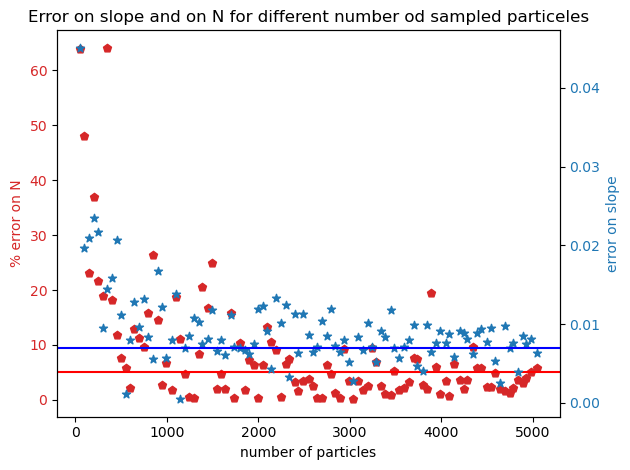

 blue and red colors showing the same value accordingly to colored axes


In [23]:
print('With parameters: LOD_low=',LOD_low,'LOD_high=',LOD_high,'slope=',slope_th)
tableau_recapitulatif_particles

serr=tableau_recapitulatif_particles['Error on slope']
Nerr=tableau_recapitulatif_particles['% error']
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('number of particles')
ax1.set_ylabel('% error on N', color=color)
ax1.scatter(tableau_recapitulatif_particles['Number of sampled particles'],Nerr, color=color, marker='p')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(y=5,xmin=0,xmax=5000,color='r')

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('error on slope', color=color)  # we already handled the x-label with ax1
ax2.scatter(tableau_recapitulatif_particles['Number of sampled particles'],np.absolute(serr), color=color, marker='*')
ax2.tick_params(axis='y', labelcolor=color)
ax2.axhline(y=0.007,xmin=0,xmax=5000,color='b')

plt.title('Error on slope and on N for different number od sampled particeles')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

print(' blue and red colors showing the same value accordingly to colored axes')

### LOD low - using irregular bins step*2

In [24]:
# Adapted version for slope changes
def simulated_sampling(LOD_min_ss,LOD_max_ss, b_ss, samples_ss):
    
    """ Returns the distribution of MP sizes within the LOD interval sampled from MP 1-5000 distribution. """
    
    #part_total = sample_power_law(xmin_ss, xmax_ss, b_ss, samples_ss)
    #part_dispo = part_total[(part_total > LOD_min_ss) & (part_total < LOD_max_ss)]

    part_dispo = sample_power_law(LOD_min_ss, LOD_max_ss, b_ss, samples_ss)
    
    if len(part_dispo) == 0:
        print('Problem: there are no particles in the LOD range',LOD_min_ss,LOD_max_ss)
        return np.array([]) 

    size_distribution = np.sort(part_dispo)

    return size_distribution
    

In [25]:
#slope
slope_th = -2.

# MP range
xmin = 1
xmax = 5000

# Physical limits of detection
LOD_low = np.arange(10,1010,100)
LOD_high = 4500

# Sampling                    
sampling_campaigns = 100                         
number_of_particles_sampled = 1000     

# Multiple sampling campaigns
n_sampled=[]
all_samplings_lod=[]
for j in range(len(LOD_low)):
    all_samplings=[]
    number_of_particles=[]
    for i in range(sampling_campaigns):
        random_sequence = np.random.uniform(0, 1, number_of_particles_sampled)
        size_distribution=simulated_sampling(LOD_min_ss=LOD_low[j],LOD_max_ss=LOD_high, b_ss=slope_th, samples_ss=random_sequence)
        all_samplings.append(size_distribution)
        number_of_particles.append(len(size_distribution))
    all_samplings_lod.append(all_samplings)
    n_sampled.append(np.mean(number_of_particles))
    

In [26]:
"""
# Regular bins
bin_length = 150
regular_bins = np.arange(LOD_low,LOD_high+1-100,bin_length)
"""

# Irregular bins
all_irregular_bins=[]
for i in range(len(LOD_low)):
    initial_step = 5
    irregular_bins=[]
    step = initial_step
    current_edge = LOD_low[i]
    edges = [current_edge]

    while True:
        next_step = step
        current_edge += next_step
        if current_edge > LOD_high:
            break
        edges.append(current_edge)
        step *= 2  # next step doubles
    irregular_bins = edges
    all_irregular_bins.append(irregular_bins)

"""
# Random bins
bin_length_random=np.array([10,15,30,30,50,50,100,100,125,205,200,200,200,200,200,200,400,400,500,500])
typical_bins=[LOD_low]
for length in bin_length_random:
    next_bin = typical_bins[-1] + length
    if next_bin <= LOD_high:
        typical_bins.append(next_bin)
    else:
        break  
typical_bins = np.array(typical_bins)
"""

'\n# Random bins\nbin_length_random=np.array([10,15,30,30,50,50,100,100,125,205,200,200,200,200,200,200,400,400,500,500])\ntypical_bins=[LOD_low]\nfor length in bin_length_random:\n    next_bin = typical_bins[-1] + length\n    if next_bin <= LOD_high:\n        typical_bins.append(next_bin)\n    else:\n        break  \ntypical_bins = np.array(typical_bins)\n'

[1000  679  402  240  111   55   24   13    3    1]


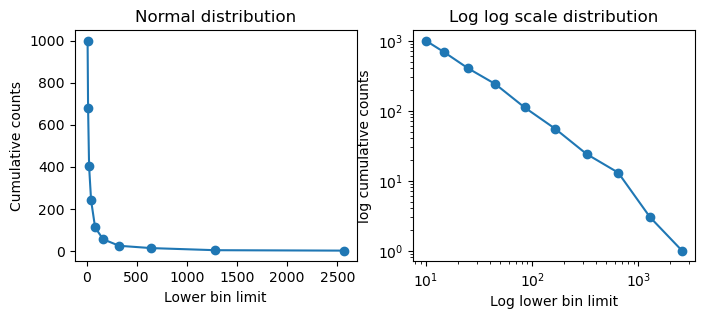

In [27]:
lower_bin_limits = all_irregular_bins
all_cumulative_counts_lod=[]
for j in range(len(LOD_low)):
    used_bin_limits=lower_bin_limits[j]
    all_cumulative_counts=[]
    for i in range(sampling_campaigns):
        cumulative_counts = np.array([(all_samplings_lod[j][i] >=limit).sum() for limit in used_bin_limits])
        all_cumulative_counts.append(cumulative_counts)
        if i == 0 and j==0:
            print(cumulative_counts)
            fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(8, 3))

            ax1.plot(used_bin_limits, cumulative_counts, marker='o')
            ax1.set_xlabel('Lower bin limit')
            ax1.set_ylabel("Cumulative counts")
            ax1.set_title('Normal distribution')

            ax2.loglog(used_bin_limits, cumulative_counts, marker='o')
            ax2.set_xlabel('Log lower bin limit')
            ax2.set_ylabel("log cumulative counts")
            ax2.set_title('Log log scale distribution')
            plt.show()

    all_cumulative_counts_lod.append(all_cumulative_counts)
    

In [28]:
minimal_bins_used = 5
counts_kept_all_lod=[]
bins_kept_all_lod=[]
for j in range(len(LOD_low)):
    used_bin_limits=lower_bin_limits[j]
    counts_kept_all=[]
    bins_kept_all=[]
    for i in range(sampling_campaigns):
        counts=all_cumulative_counts_lod[j][i]
        counts_kept = counts[:minimal_bins_used]
        bins_kept = used_bin_limits[:minimal_bins_used]
        counts_kept_all.append(counts_kept)
        bins_kept_all.append(bins_kept)
    counts_kept_all_lod.append(counts_kept_all)
    bins_kept_all_lod.append(bins_kept_all)

/tmp/ipykernel_47561/1552108755.py:5: RuntimeWarning: divide by zero encountered in log10
  log_counts = np.log10(all_cumulative_counts_lod)


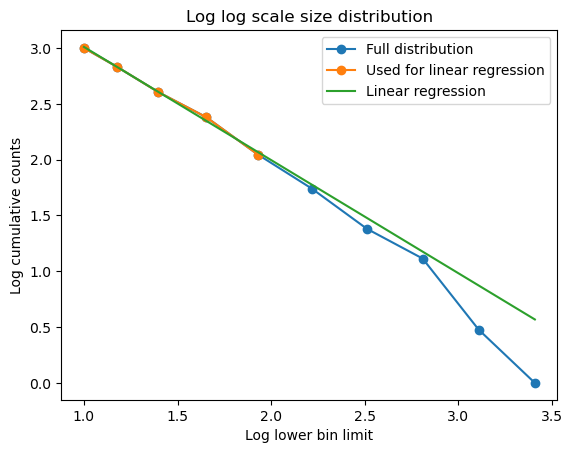

In [29]:
all_slopes_cumsum_lod=[]
all_intercepts_cumsum_lod=[]

log_bins = np.log10(lower_bin_limits)
log_counts = np.log10(all_cumulative_counts_lod)
log_bins_kept_all_lod = np.log10(bins_kept_all_lod)
log_counts_kept_all_lod = np.log10(counts_kept_all_lod)

for j in range(len(LOD_low)):
    used_bin_limits=log_bins[j]
    all_slopes_cumsum=[]
    all_intercepts_cumsum=[]
    for i in range(sampling_campaigns):
        slope_cumsum=linregress(log_bins_kept_all_lod[j][i],log_counts_kept_all_lod[j][i]).slope
        intercept_cumsum=linregress(log_bins_kept_all_lod[j][i],log_counts_kept_all_lod[j][i]).intercept
        if i == 0 and j==0:
            plt.plot(used_bin_limits,log_counts[j][i],marker='o',label='Full distribution')
            plt.plot(log_bins_kept_all_lod[j][i],log_counts_kept_all_lod[j][i],marker='o',label='Used for linear regression')
            plt.plot(used_bin_limits,slope_cumsum*used_bin_limits+intercept_cumsum, label='Linear regression')
            plt.xlabel('Log lower bin limit')
            plt.ylabel("Log cumulative counts")
            plt.title('Log log scale size distribution')
            plt.legend()
            plt.show()
        all_slopes_cumsum.append(slope_cumsum)
        all_intercepts_cumsum.append(intercept_cumsum)
    all_slopes_cumsum_lod.append(all_slopes_cumsum)
    all_intercepts_cumsum_lod.append(all_intercepts_cumsum)
    

In [30]:
all_slopes_lod = np.array(all_slopes_cumsum_lod)-1
all_slopes_err_lod = all_slopes_lod-slope_th
all_slopes_err_lod_mean=[]
all_N_lod=[]
all_N_err_lod=[]

for j in range(len(LOD_low)):
    all_N=[]

    for i in range(sampling_campaigns):
        N_1 = all_slopes_cumsum_lod[j][i]*np.log10(1)+all_intercepts_cumsum_lod[j][i]
        N_5000=(all_slopes_cumsum_lod[j][i]*np.log10(5000)+all_intercepts_cumsum_lod[j][i])
        N = 10**N_1-10**N_5000
        all_N.append(N)

    all_N_err=np.absolute(all_N-np.mean(all_N))  
    all_N_lod.append(np.mean(all_N))
    all_N_err_lod.append(np.mean(all_N_err))
    all_slopes_err_lod_mean.append(np.mean(all_slopes_err_lod[j]))
    


In [31]:
tableau_recapitulatif_lod = pd.DataFrame({
    'Lower LOD': LOD_low,
    'Calculated number of particles': all_N_lod,
    'Difference between N and N calcluated': all_N_err_lod,
    '% error':(np.array(np.absolute(all_N_err_lod))*100)/np.array(all_N_lod),
    'Number of sampled particles':n_sampled,
    'Error on slope':all_slopes_err_lod_mean
})
tableau_recapitulatif_lod['Calculated number of particles'] = tableau_recapitulatif_lod['Calculated number of particles'].round(0).astype(int)
tableau_recapitulatif_lod['Difference between N and N calcluated'] = tableau_recapitulatif_lod['Difference between N and N calcluated'].round(0).astype(int)
tableau_recapitulatif_lod['Number of sampled particles '] = tableau_recapitulatif_lod['Number of sampled particles'].round(0).astype(int)

print(np.mean(all_N_err))


8665062.796174701


- Initial number of particles : number of particles within 1-5000 range imposed as a parameter
- Calculated number of particles : Number of particles calculated with the cumulative sum method, mean over all sampling campaigns
- Difference between N and N calcluated : mean value over all sampling campaigns, difference between calculated and initial  # of particles.
- % error : mean difference out of initial number of particles in percentage
- Number of sampled particles : mean value over all sampling campaigns
- Error on slope : difference between calulated slope and original slope, mean over all samplings

Over-estimation and under-estimation depends on the slope. One has to choose carefully which points will be included in the linear regression.  

In [34]:
print('With parameters: n =',number_of_particles_sampled,'LOD_high =',LOD_high,'slope =',slope_th)
tableau_recapitulatif_lod


With parameters: n = 1000 LOD_high = 4500 slope = -2.0


,Lower LOD,Calculated number of particles,Difference between N and N calcluated,% error,Number of sampled particles,Error on slope,Number of sampled particles
0,10,10320,862,8.352636,1000.0,-0.008932,1000
1,110,130864,24641,18.829632,1000.0,-0.030708,1000
2,210,307474,91171,29.651752,1000.0,-0.058106,1000
3,310,558058,194605,34.871776,1000.0,-0.085956,1000
4,410,876162,350361,39.988105,1000.0,-0.104335,1000
5,510,1274231,496454,38.961072,1000.0,-0.125648,1000
6,610,2186388,1289305,58.969612,1000.0,-0.155056,1000
7,710,3276065,1617084,49.360556,1000.0,-0.202056,1000
8,810,5686015,3917625,68.899308,1000.0,-0.238337,1000
9,910,10329057,8665063,83.890166,1000.0,-0.273753,1000


With parameters: n = 1000 LOD_high= 4500 slope= -2.0


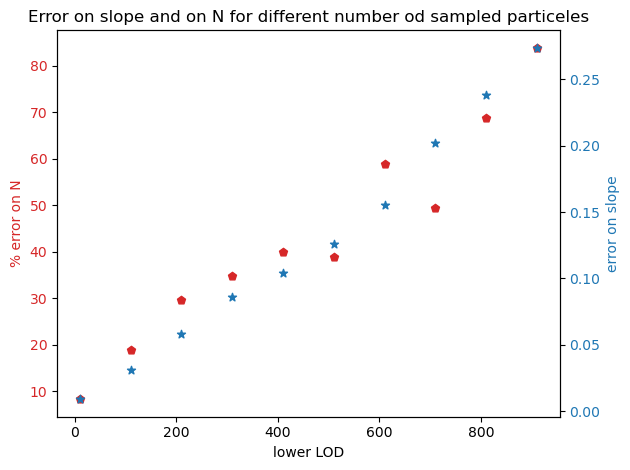

In [35]:

print('With parameters: n =',1000,'LOD_high=',LOD_high,'slope=',slope_th)

serr=tableau_recapitulatif_lod['Error on slope']
Nerr=tableau_recapitulatif_lod['% error']
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('lower LOD')
ax1.set_ylabel('% error on N', color=color)
ax1.scatter(tableau_recapitulatif_lod['Lower LOD'],Nerr, color=color, marker='p')
ax1.tick_params(axis='y', labelcolor=color)
#ax1.axhline(y=5,xmin=0,xmax=5000,color='r')

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('error on slope', color=color)  # we already handled the x-label with ax1
ax2.scatter(tableau_recapitulatif_lod['Lower LOD'],np.absolute(serr), color=color, marker='*')
ax2.tick_params(axis='y', labelcolor=color)
#ax2.axhline(y=0.007,xmin=0,xmax=5000,color='b')

plt.title('Error on slope and on N for different number od sampled particeles')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

As we can see, the number of calculated particles greatly depends on the interval defined by the limits of detection (LOD). The precision is determined by the LOD interval, even though the minimum number of particles remains 1000 as in the first table. Since at the tail of a power-law distribution the particle count is lower and the slope is shallower, an error in the slope can cause a significant bias in the total number of microplastics estimated over the full range (1–5000 μm). Therefore, studies with a lower limit of detection above 900 μm are of limited use, as their data do not allow for accurate slope estimation which is necessary for a correct particle count.

### Slope - using irregular bins step*2

In [36]:
# Adapted version for slope changes
def simulated_sampling(LOD_min_ss,LOD_max_ss, b_ss, samples_ss):
    
    """ Returns the distribution of MP sizes within the LOD interval sampled from MP 1-5000 distribution. """
    
    #part_total = sample_power_law(xmin_ss, xmax_ss, b_ss, samples_ss)
    #part_dispo = part_total[(part_total > LOD_min_ss) & (part_total < LOD_max_ss)]

    part_dispo = sample_power_law(LOD_min_ss, LOD_max_ss, b_ss, samples_ss)
    
    if len(part_dispo) == 0:
        print('Problem: there are no particles in the LOD range',LOD_min_ss,LOD_max_ss)
        return np.array([]) 

    size_distribution = np.sort(part_dispo)

    return size_distribution
    

In [37]:
#slope
slope_th = np.arange(-3.8,-1.1,0.15)

# MP range
xmin = 1
xmax = 5000

# Physical limits of detection
LOD_low = 10
LOD_high = 4500

# Sampling                    
sampling_campaigns = 100                         
number_of_particles_sampled = 10000     

# Multiple sampling campaigns
n_sampled=[]
all_samplings_slope=[]
for j in range(len(slope_th)):
    all_samplings=[]
    number_of_particles=[]
    for i in range(sampling_campaigns):
        random_sequence = np.random.uniform(0, 1, number_of_particles_sampled)
        size_distribution=simulated_sampling(LOD_min_ss=LOD_low,
                                                LOD_max_ss=LOD_high, b_ss=slope_th[j], samples_ss=random_sequence)
        all_samplings.append(size_distribution)
        number_of_particles.append(len(size_distribution))
    all_samplings_slope.append(all_samplings)
    n_sampled.append(np.mean(number_of_particles))


In [38]:

"""# Bins
# Regular bins
bin_length = 10
all_regular_bins=[]
for i in range(len(LOD_low)):
    regular_bins = np.arange(LOD_low[i],LOD_high+1-100,bin_length)
    all_regular_bins.append(regular_bins)
"""
# Irregular bins
all_irregular_bins=[]
for i in range(len(slope_th)):
    initial_step = 5
    irregular_bins=[]
    step = initial_step
    current_edge = LOD_low
    edges = [current_edge]

    while True:
        next_step = step
        current_edge += next_step
        if current_edge > LOD_high:
            break
        edges.append(current_edge)
        step *= 2  # next step doubles
    irregular_bins = edges
    all_irregular_bins.append(irregular_bins)
    
"""   
# Random bins
all_random_bins=[]
bin_length_random=np.array([10,15,30,30,50,50,100,100,125,205,200,200,200,200,200,200,400,400,500,500])
for i in range(len(LOD_low)):
    random_bins=[LOD_low[i]]
    for length in bin_length_random:
        next_bin = random_bins[-1] + length
        if next_bin <= LOD_high:
            random_bins.append(next_bin)
        else:
            break  
    random_bins = np.array(random_bins)
    all_random_bins.append(random_bins)
"""


'   \n# Random bins\nall_random_bins=[]\nbin_length_random=np.array([10,15,30,30,50,50,100,100,125,205,200,200,200,200,200,200,400,400,500,500])\nfor i in range(len(LOD_low)):\n    random_bins=[LOD_low[i]]\n    for length in bin_length_random:\n        next_bin = random_bins[-1] + length\n        if next_bin <= LOD_high:\n            random_bins.append(next_bin)\n        else:\n            break  \n    random_bins = np.array(random_bins)\n    all_random_bins.append(random_bins)\n'

[10000  3231   777   156    33     3     1     0     0     0]


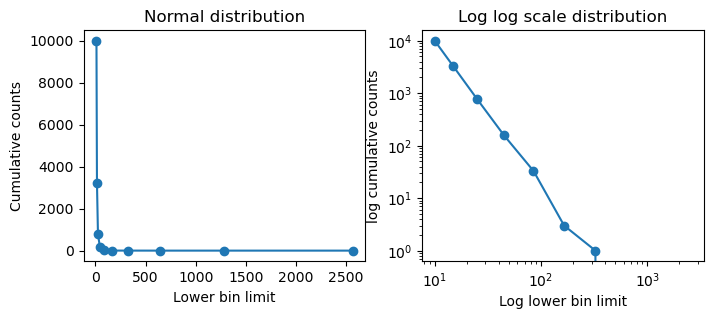

In [39]:
lower_bin_limits = all_irregular_bins
all_cumulative_counts_slope=[]
for j in range(len(slope_th)):
    used_bin_limits=lower_bin_limits[j]
    all_cumulative_counts=[]
    for i in range(sampling_campaigns):
        cumulative_counts = np.array([(all_samplings_slope[j][i] >=limit).sum() for limit in used_bin_limits])
        all_cumulative_counts.append(cumulative_counts)
        if i == 0 and j==0:
            print(cumulative_counts)
            fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(8, 3))

            ax1.plot(used_bin_limits, cumulative_counts, marker='o')
            ax1.set_xlabel('Lower bin limit')
            ax1.set_ylabel("Cumulative counts")
            ax1.set_title('Normal distribution')

            ax2.loglog(used_bin_limits, cumulative_counts, marker='o')
            ax2.set_xlabel('Log lower bin limit')
            ax2.set_ylabel("log cumulative counts")
            ax2.set_title('Log log scale distribution')
            plt.show()

    all_cumulative_counts_slope.append(all_cumulative_counts)
    

In [40]:
minimal_bins_used = 6
counts_kept_all_slope=[]
bins_kept_all_slope=[]
for j in range(len(slope_th)):
    used_bin_limits=lower_bin_limits[j]
    counts_kept_all=[]
    bins_kept_all=[]
    for i in range(sampling_campaigns):
        counts=all_cumulative_counts_slope[j][i]
        counts_kept = counts[:minimal_bins_used]
        bins_kept = used_bin_limits[:minimal_bins_used]
        counts_kept_all.append(counts_kept)
        bins_kept_all.append(bins_kept)
    counts_kept_all_slope.append(counts_kept_all)
    bins_kept_all_slope.append(bins_kept_all)

/tmp/ipykernel_47561/1416656153.py:5: RuntimeWarning: divide by zero encountered in log10
  log_counts = np.log10(all_cumulative_counts_slope)
/tmp/ipykernel_47561/1416656153.py:7: RuntimeWarning: divide by zero encountered in log10
  log_counts_kept_all_slope = np.log10(counts_kept_all_slope)


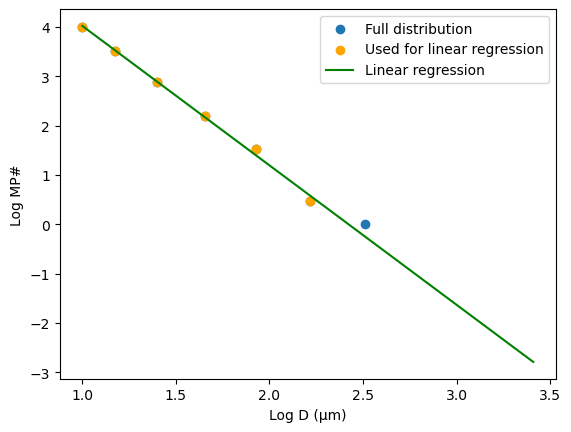

/opt/conda/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2842: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


In [44]:
all_slopes_cumsum_slope=[]
all_intercepts_cumsum_slope=[]

log_bins = np.log10(lower_bin_limits)
log_counts = np.log10(all_cumulative_counts_slope)
log_bins_kept_all_slope = np.log10(bins_kept_all_slope)
log_counts_kept_all_slope = np.log10(counts_kept_all_slope)

for j in range(len(slope_th)):
    used_bin_limits=log_bins[j]
    all_slopes_cumsum=[]
    all_intercepts_cumsum=[]
    for i in range(sampling_campaigns):
        slope_cumsum=linregress(log_bins_kept_all_slope[j][i],log_counts_kept_all_slope[j][i]).slope
        intercept_cumsum=linregress(log_bins_kept_all_slope[j][i],log_counts_kept_all_slope[j][i]).intercept
        if i == 0 and j==0:
            plt.scatter(used_bin_limits,log_counts[j][i],marker='o',label='Full distribution')
            plt.scatter(log_bins_kept_all_slope[j][i],log_counts_kept_all_slope[j][i],marker='o',label='Used for linear regression',color='orange')
            plt.plot(used_bin_limits,slope_cumsum*used_bin_limits+intercept_cumsum, label='Linear regression',color='green')
            plt.xlabel('Log D (μm)')
            plt.ylabel("Log MP#")
            plt.title('')
            plt.legend()
            plt.show()
        all_slopes_cumsum.append(slope_cumsum)
        all_intercepts_cumsum.append(intercept_cumsum)
    all_slopes_cumsum_slope.append(all_slopes_cumsum)
    all_intercepts_cumsum_slope.append(all_intercepts_cumsum)


In [45]:
all_slopes_slope = np.array(all_slopes_cumsum_slope)-1
all_slopes_err_slope_mean=[]
all_N_slope=[]
all_N_err_slope=[]

for j in range(len(slope_th)):
    all_N=[]
    all_N_err=[]
    for i in range(sampling_campaigns):
        N_1 = all_slopes_cumsum_slope[j][i]*np.log10(1)+all_intercepts_cumsum_slope[j][i]
        N_5000=(all_slopes_cumsum_slope[j][i]*np.log10(5000)+all_intercepts_cumsum_slope[j][i])
        N = 10**N_1-10**N_5000
        all_N.append(N)
    all_N_err=np.absolute(all_N-np.mean(all_N))   
        
    all_N_slope.append(np.mean(all_N))
    all_N_err_slope.append(np.mean(all_N_err))

    all_slopes_err_slope=np.absolute(all_slopes_slope[j]-slope_th[j])
    all_slopes_err_slope_mean.append(np.nanmean(all_slopes_err_slope))


In [46]:
tableau_recapitulatif_slope = pd.DataFrame({
    'slope_th': slope_th,
    '% error':(np.array(np.absolute(all_N_err_slope))*100)/np.array(all_N_slope),
    'Error on slope': all_slopes_err_slope_mean,
    'Number of sampled particles':n_sampled,
})
tableau_recapitulatif_slope['Number of sampled particles'] = tableau_recapitulatif_slope['Number of sampled particles'].round(0).astype(int)



- Initial number of particles : number of particles within 1-5000 range imposed as a parameter
- Calculated number of particles : Number of particles calculated with the cumulative sum method, mean over all sampling campaigns
- Difference between N and N calcluated : mean value over all sampling campaigns, difference between calculated and initial  # of particles.
- % error : mean difference out of initial number of particles in percentage
- Number of sampled particles : mean value over all sampling campaigns
- Error on slope : difference between calulated slope and original slope, mean over all samplings

Over-estimation and under-estimation depends on the slope. One has to choose carefully which points will be included in the linear regression.  

In [47]:
print('With parameters: LOD_low =',LOD_low,'LOD_high =',LOD_high)
tableau_recapitulatif_slope

With parameters: LOD_low = 10 LOD_high = 4500


,slope_th,% error,Error on slope,Number of sampled particles
0,-3.80,43.690448,0.134588,10000
1,-3.65,NaN,0.116496,10000
2,-3.50,23.617095,0.081667,10000
3,-3.35,18.929343,0.065505,10000
4,-3.20,17.245597,0.058992,10000
5,-3.05,13.807524,0.045910,10000
6,-2.90,9.221879,0.032748,10000
7,-2.75,7.598574,0.027733,10000
8,-2.60,7.432931,0.026334,10000
9,-2.45,6.298131,0.022646,10000


With parameters: n = 10000 LOD_high= 4500 LOD_low= 10


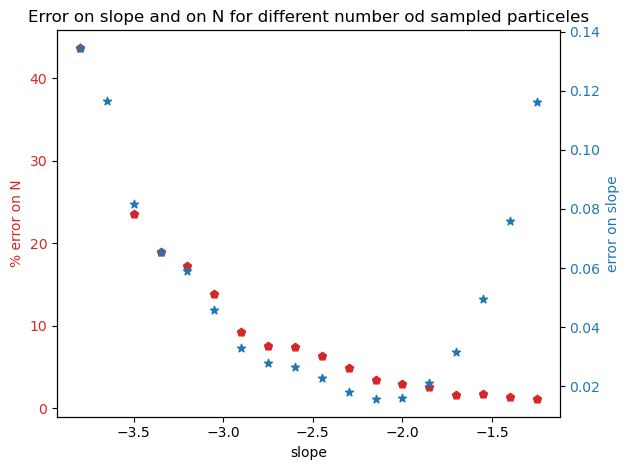

In [48]:
print('With parameters: n =',10000,'LOD_high=',LOD_high,'LOD_low=',LOD_low)

serr=tableau_recapitulatif_slope['Error on slope']
Nerr=tableau_recapitulatif_slope['% error']
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('slope')
ax1.set_ylabel('% error on N', color=color)
ax1.scatter(tableau_recapitulatif_slope['slope_th'],Nerr, color=color, marker='p')
ax1.tick_params(axis='y', labelcolor=color)
#ax1.axhline(y=5,xmin=0,xmax=5000,color='r')

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('error on slope', color=color)  # we already handled the x-label with ax1
ax2.scatter(tableau_recapitulatif_slope['slope_th'],serr, color=color, marker='*')
ax2.tick_params(axis='y', labelcolor=color)
#ax2.axhline(y=0.007,xmin=0,xmax=5000,color='b')

plt.title('Error on slope and on N for different number od sampled particeles')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

This notebook demonstrates that the use of cumulative sum is effective for estimating the true slope of a power-law distribution of particles in log-log scale. In all samplings, the selected bins were irregular, following a specific pattern $step*2$. This binning pattern was identified as the most suitable across tested scenarios  in notebook 2 - Binning options.

We tested the cumulative sum method while varying the total number of particles (N) in the matrix from 1,000 to 101,000, with a fixed slope of -2.0 and a sampling range between 10 and 4550. Even when only 100 particles were sampled, the estimated total number of particles remained within the correct order of magnitude, and the slope error was limited to 0.03.

We also tested the method by varying the lower limit of detection (LOD) from 10 to 1910, keeping the slope at -2.0 and N at 1,000,000. The total number of particles remained in the correct order of magnitude for LOD values up to 910. This suggests that studies with LODs higher than 900 (at least) should be excluded if the goal is to assess the abundance of small particles. An acceptable error on the slope is around 0.3. Beyond this threshold, errors in the slope lead to significant inaccuracies in the particle size distribution over the full range of 1–5000.

The method was further tested by varying the original slope of the power-law distribution from -1.1 to -3.8, with N fixed at 100,000 and the sampling range between 10 and 4550. The error on the total number of particles is of 40% for slope < -3.0 but appears independent of the slope for slope > -3.0 . However, the biger the absolute value of the slope (slopes around 1), the greater the error observed in its estimation. Neverless, fos biger slopes, the error on slope does not have a grat influence on N.

A key point is that the tail of the distribution should be excluded from the regression, as it does not follow a linear trend in log-log scale. Consequently, the precision of the slope depends on the chosen threshold for the minimum number of particles per bin. This threshold must be determined individually for each study, as it is highly sensitive to the initial sampling parameters.
